# C3_other_sound — 무라벨(라벨링 없이) 획득

AudioSet 527클래스로 학습된 AST(MIT/ast-finetuned-audioset-10-10-0.4593)를 제로샷 태거로 사용해, 어른 음성 계열(Male/Female speech, Conversation 등)과 기계·매체음 계열(Vacuum, Fan, TV, Music 등)의 최대 확률 p_other 를 아기 계열(Baby cry, Babbling, Child speech 등)의 p_baby 와 비교하는 의사라벨링이다. p_other ≥ 0.2 이고 p_other > p_baby 이면 양성으로 판정하며, manifest 의 sound_frac == 0 인 무음 클립은 모델을 거치지 않아 T4 1개로 1000클립을 빠르게 처리한다. 이진 라벨과 함께 연속 점수(p_adult, p_mach, p_baby)를 저장해 검증 셀의 분포를 보고 임계값을 사후 조정할 수 있다. 8kHz AAC 오디오는 PyAV 로 디코드 후 torchaudio 로 16kHz 리샘플한다.

In [1]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080


In [5]:
!pip install -q transformers torchaudio av decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 125.2 MB/s eta 0:00:00


## C3_other_sound — 비아기 소음(어른 목소리·기계음) 자동 라벨

**방법**: AudioSet 527클래스로 학습된 **AST**(Audio Spectrogram Transformer, `MIT/ast-finetuned-audioset-10-10-0.4593`)로 각 클립 오디오를 제로샷 태깅한다.
어른 음성 계열(Male/Female speech, Conversation, Narration …)과 기계·매체음 계열(Vacuum, Fan, TV, Music …)의 최대 확률 `p_other` 를
아기 계열(Baby cry, Babbling, Child speech …)의 `p_baby` 와 비교해 **`p_other ≥ 0.2` 이고 `p_other > p_baby` 이면 양성** 의사라벨을 부여한다.
manifest 의 `sound_frac == 0`(무음) 클립은 모델을 거치지 않고 음성 판정한다. 수동 라벨 불필요.

- AST 논문: [arXiv:2104.01778](https://arxiv.org/abs/2104.01778) (Gong et al., Interspeech 2021)
- 모델 카드: [MIT/ast-finetuned-audioset-10-10-0.4593](https://huggingface.co/MIT/ast-finetuned-audioset-10-10-0.4593)
- 대안 태거 PANNs: [arXiv:1912.10211](https://arxiv.org/abs/1912.10211) (Kong et al., TASLP 2020)
- AudioSet 온톨로지: [Gemmeke et al., ICASSP 2017](https://research.google/pubs/audio-set-an-ontology-and-human-labeled-dataset-for-audio-events/)

**주의**: 소스 오디오가 8 kHz 라 4 kHz 이상 대역이 없다. AST 는 16 kHz 입력을 기대하므로 리샘플하되, 대역 손실로 확률이 전반적으로 낮게 나올 수 있어 임계값을 0.2 로 두고 검증 셀에서 분포를 보고 조정한다.

In [3]:
import torch, numpy as np
from transformers import ASTFeatureExtractor, ASTForAudioClassification

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'
extractor = ASTFeatureExtractor.from_pretrained(MODEL_ID)
ast = ASTForAudioClassification.from_pretrained(MODEL_ID).to(DEVICE).eval()
if DEVICE == 'cuda':
    ast = ast.half()  # T4 fp16 — 수치 문제가 보이면 이 줄 제거
id2label = ast.config.id2label  # {int: 클래스명} 527개

def _idx(keys):
    """클래스명 부분일치로 인덱스 그룹 구성 (AudioSet 온톨로지 기반)"""
    keys = [k.lower() for k in keys]
    return [i for i, n in id2label.items() if any(k in n.lower() for k in keys)]

BABY_IDX = _idx(['baby cry', 'crying, sobbing', 'babbling', 'baby laughter',
                 'whimper', 'child speech', 'children'])
ADULT_IDX = _idx(['male speech', 'female speech', 'conversation',
                  'narration', 'speech synthesizer'])
MACH_IDX = _idx(['vacuum', 'mechanical fan', 'air conditioning', 'television',
                 'white noise', 'music', 'water tap', 'dishes', 'telephone',
                 'microwave', 'blender', 'washing machine', 'door', 'drill',
                 'engine', 'siren'])
print(f'클래스 수: baby={len(BABY_IDX)}, adult={len(ADULT_IDX)}, mach={len(MACH_IDX)}')

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

클래스 수: baby=10, adult=5, mach=74


In [6]:
import av, torchaudio

SR = 16000

def load_audio(path, target_sr=SR):
    """mp4 의 AAC 트랙을 mono float32 로 디코드 후 16 kHz 리샘플"""
    con = av.open(str(path))
    if not con.streams.audio:
        con.close(); return None
    st = con.streams.audio[0]; sr = st.rate
    chunks = []
    for fr in con.decode(st):
        a = fr.to_ndarray()
        if a.dtype.kind == 'i':
            a = a.astype(np.float32) / np.iinfo(a.dtype).max
        a = a.astype(np.float32)
        chunks.append(a.mean(axis=0) if a.ndim > 1 else a)
    con.close()
    if not chunks:
        return None
    x = np.concatenate(chunks)
    if sr != target_sr:
        x = torchaudio.functional.resample(torch.from_numpy(x), sr, target_sr).numpy()
    return x

@torch.no_grad()
def process_clip(path, row):
    out = {'file': row['file'], 'p_adult': 0.0, 'p_mach': 0.0, 'p_baby': 0.0,
           'p_other': 0.0, 'top_class': '', 'top_p': 0.0, 'label': 0, 'note': ''}
    sf = row.get('sound_frac', 0)
    if sf == 0 or pd.isna(sf):        # manifest 상 무음 → 모델 생략
        out['note'] = 'silent'; return out
    x = load_audio(path)
    if x is None or len(x) < SR // 4:
        out['note'] = 'no_audio'; return out
    feats = extractor(x[:SR * 10], sampling_rate=SR, return_tensors='pt')
    iv = feats['input_values'].to(DEVICE)
    if next(ast.parameters()).dtype == torch.float16:
        iv = iv.half()
    probs = torch.sigmoid(ast(input_values=iv).logits)[0].float().cpu().numpy()
    out['p_adult'] = float(probs[ADULT_IDX].max())
    out['p_mach'] = float(probs[MACH_IDX].max())
    out['p_baby'] = float(probs[BABY_IDX].max())
    out['p_other'] = max(out['p_adult'], out['p_mach'])
    ti = int(probs.argmax())
    out['top_class'], out['top_p'] = id2label[ti], float(probs[ti])
    out['label'] = int(out['p_other'] >= 0.20 and out['p_other'] > out['p_baby'])
    return out

In [7]:
OUT_CSV = BASE / 'auto_C3_other_sound.csv'
N_CLIPS = 1000   # 표본 크기 — 전량 처리하려면 len(man) 으로

done = set()
if OUT_CSV.exists():
    done = set(pd.read_csv(OUT_CSV)['file'].astype(str))

sample = man.sample(n=min(N_CLIPS, len(man)), random_state=42)
todo = sample[~sample['file'].astype(str).isin(done)]
print(f'표본 {len(sample)}개 중 {len(todo)}개 처리 예정 (기존 {len(done)}개 건너뜀)')

buf = []
def flush():
    global buf
    if buf:
        pd.DataFrame(buf).to_csv(OUT_CSV, mode='a', index=False,
                                 header=not OUT_CSV.exists())
        buf = []

for i, (_, r) in enumerate(todo.iterrows(), 1):
    try:
        buf.append(process_clip(CLIPS / r['file'], r))
    except Exception as e:   # 개별 실패는 기록만 하고 계속
        buf.append({'file': r['file'], 'p_adult': 0.0, 'p_mach': 0.0,
                    'p_baby': 0.0, 'p_other': 0.0, 'top_class': '', 'top_p': 0.0,
                    'label': 0, 'note': f'err:{str(e)[:60]}'})
    if i % 50 == 0:
        flush(); print(f'{i}/{len(todo)} 처리 완료')
flush()

res = pd.read_csv(OUT_CSV).drop_duplicates('file', keep='last')
print(f'총 {len(res)}개 저장, other_sound 양성 비율: {res["label"].mean():.3f}')

표본 1000개 중 1000개 처리 예정 (기존 0개 건너뜀)
50/1000 처리 완료
100/1000 처리 완료
150/1000 처리 완료
200/1000 처리 완료
250/1000 처리 완료
300/1000 처리 완료
350/1000 처리 완료
400/1000 처리 완료
450/1000 처리 완료
500/1000 처리 완료
550/1000 처리 완료
600/1000 처리 완료
650/1000 처리 완료
700/1000 처리 완료
750/1000 처리 완료
800/1000 처리 완료
850/1000 처리 완료
900/1000 처리 완료
950/1000 처리 완료
1000/1000 처리 완료
총 1000개 저장, other_sound 양성 비율: 0.002


/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1503/2630075590.py:9: UserWarning: Glyph 49828 (\N{HANGUL

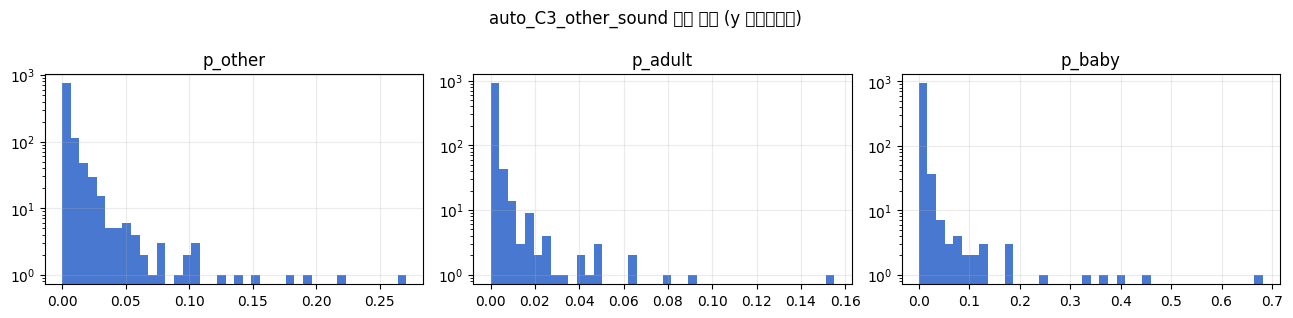

=== other_sound 상위 5 (어른 목소리/기계음 확실 사례) ===
                   file  p_other  p_adult   p_mach   p_baby top_class  label
2026-07-21_23-56-12.mp4 0.270752 0.001421 0.270752 0.000933     Music      1
2026-07-03_00-27-08.mp4 0.217651 0.000750 0.217651 0.001611     Music      1
2026-07-07_02-08-58.mp4 0.195923 0.000542 0.195923 0.000933     Sonar      0
2026-07-22_16-59-39.mp4 0.176758 0.000180 0.176758 0.000591      Slam      0
2026-07-03_20-40-42.mp4 0.155151 0.155151 0.026703 0.003708    Speech      0

=== 경계 사례: 아기 + 비아기 소리 동시 활성 ===
Empty DataFrame
Columns: [file, p_other, p_adult, p_mach, p_baby, top_class, label]
Index: []

=== label / note 분포 ===
label
0    998
1      2
Name: count, dtype: int64
note
silent    526
          474
Name: count, dtype: int64

청취: 2026-07-21_23-56-12.mp4 (p_other=0.27, top=Music)


In [8]:
import matplotlib.pyplot as plt

res = pd.read_csv(OUT_CSV).drop_duplicates('file', keep='last')
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ['p_other', 'p_adult', 'p_baby']):
    ax.hist(res[col].fillna(0), bins=40, color='#4878cf')
    ax.set_title(col); ax.set_yscale('log'); ax.grid(alpha=0.25)
plt.suptitle('auto_C3_other_sound 점수 분포 (y 로그스케일)')
plt.tight_layout(); plt.show()

cols = ['file', 'p_other', 'p_adult', 'p_mach', 'p_baby', 'top_class', 'label']
print('=== other_sound 상위 5 (어른 목소리/기계음 확실 사례) ===')
print(res.sort_values('p_other', ascending=False)[cols].head(5).to_string(index=False))

print('\n=== 경계 사례: 아기 + 비아기 소리 동시 활성 ===')
amb = res[(res['p_baby'] > 0.2) & (res['p_other'] > 0.2)]
print(amb.sort_values('p_other', ascending=False)[cols].head(5).to_string(index=False))

print('\n=== label / note 분포 ===')
print(res['label'].value_counts())
print(res['note'].fillna('').value_counts().head(5))

# 최고 점수 클립 직접 청취 (Colab 전용 — 실패해도 무방)
try:
    from IPython.display import Audio, display
    top = res.sort_values('p_other', ascending=False).iloc[0]
    print(f"\n청취: {top['file']} (p_other={top['p_other']:.2f}, top={top['top_class']})")
    display(Audio(load_audio(CLIPS / top['file']), rate=SR))
except Exception as e:
    print('오디오 재생 생략:', e)